In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("artifacts/train.csv")

date_cols = [          # قائمة باسماء اعمدة التواريخ المجودة في الجدول المستورد من المهمة الاولى
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for CL in date_cols :
    if CL in df.columns:
        df[CL] = pd.to_datetime(df[CL])

print(f"Trian Shape is : {df.shape}")
print(f"Data Type in Train Set is : ")
print(df.dtypes.value_counts)            # عدد العناوين من نفس النوع 


Trian Shape is : (67530, 16)
Data Type in Train Set is : 
<bound method IndexOpsMixin.value_counts of order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_state                              str
customer_city                               str
total_items                             float64
total_price                             float64
total_freight                           float64
total_payment                           float64
max_installments                        float64
is_late                                   int64
dtype: object>


In [3]:
# . إنشاء جدول البيانات بشكل صحيح بالاستدعاء ()
missing = pd.DataFrame(
    {
        "Missing Count": df.isnull().sum(),
        "Missing %": (df.isnull().sum() / len(df)) * 100,
    }
)

# . تصفية الأعمدة التي تحتوي على قيم مفقودة وترتيبها
missing_summary = missing[missing["Missing Count"] > 0].sort_values(
    by="Missing Count", ascending=False
)

print("* The Deficient values in data *")
print(missing_summary)

* The Deficient values in data *
                              Missing Count  Missing %
order_approved_at                        12   0.017770
order_delivered_carrier_date              1   0.001481


--- إحصائيات المتغيرات الرقمية ---
                    count        mean         std   min    25%    50%  \
total_items       67530.0    1.141211    0.534071  1.00   1.00   1.00   
total_price       67530.0  137.706404  213.627260  0.85  45.90  86.99   
total_freight     67530.0   22.867222   22.170543  0.00  13.86  17.19   
max_installments  67530.0    2.932741    2.719194  0.00   1.00   2.00   

                       75%       max   skewness  
total_items         1.0000     20.00   7.196905  
total_price       149.9000  13440.00  11.028492  
total_freight      24.1075   1794.96  14.183905  
max_installments    4.0000     24.00   1.605844  


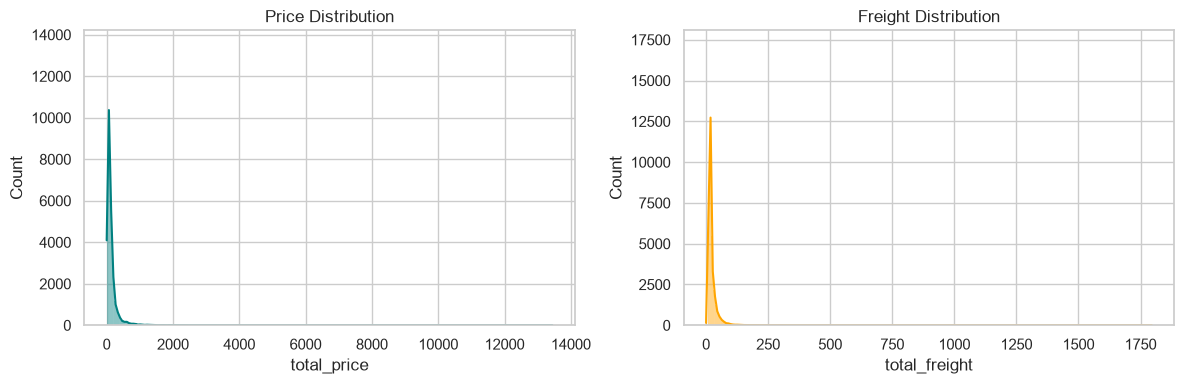

In [4]:
# إحصائيات للمتغيرات الرقمية وتحديد القيم الشاذة والالتواء
num_cols = ["total_items", "total_price", "total_freight", "max_installments"]
num_summary = df[num_cols].describe().T
num_summary["skewness"] = df[num_cols].skew()

print("--- إحصائيات المتغيرات الرقمية ---")
print(num_summary)

# رسم التوزيعات لمعاينة الالتواء (Skew)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["total_price"], kde=True, ax=axes[0], color="teal").set_title(
    "Price Distribution"
)
sns.histplot(df["total_freight"], kde=True, ax=axes[1], color="orange").set_title(
    "Freight Distribution"
)
plt.tight_layout()
plt.show()

In [5]:
cat_cols=["customer_state", "customer_city"]
for col in cat_cols:
    if col in df.columns:
        print(f"***Column : {col} ***")
        print(f"***Number of unique value(Cardinality): {df[col].nunique()} ***")
        print(f"*** 5 Heigth repated type : ")
        print(df[col].value_counts().head(5))
        print("-" * 30)

***Column : customer_state ***
***Number of unique value(Cardinality): 27 ***
*** 5 Heigth repated type : 
customer_state
SP    28314
RJ     8631
MG     7948
RS     3739
PR     3479
Name: count, dtype: int64
------------------------------
***Column : customer_city ***
***Number of unique value(Cardinality): 3668 ***
*** 5 Heigth repated type : 
customer_city
sao paulo         10521
rio de janeiro     4640
belo horizonte     1896
brasilia           1476
curitiba           1082
Name: count, dtype: int64
------------------------------


*** Percentage of delayed application in the top 10 states by application volume ***
                count  late_rate
customer_state                  
SP              28314   0.058310
RJ               8631   0.137180
MG               7948   0.057499
RS               3739   0.067130
PR               3479   0.050589
SC               2460   0.098780
BA               2297   0.135394
DF               1482   0.069501
ES               1409   0.124911
GO               1379   0.081218


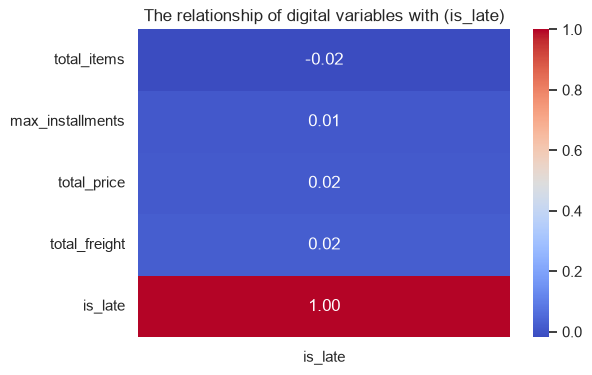

In [6]:
state_late =(
    df.groupby("customer_state")["is_late"]
    .agg(["count", "mean"])
    .sort_values(by="count", ascending=False)
)
state_late.rename(columns={"mean": "late_rate"} , inplace=True)
print("*** Percentage of delayed application in the top 10 states by application volume ***")
print(state_late.head(10))


plt.figure(figsize=(6, 4))
sns.heatmap(
        df[num_cols + ["is_late"]].corr()[["is_late"]].sort_values(by="is_late"),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
    )
plt.title("The relationship of digital variables with (is_late)")
plt.show()

    


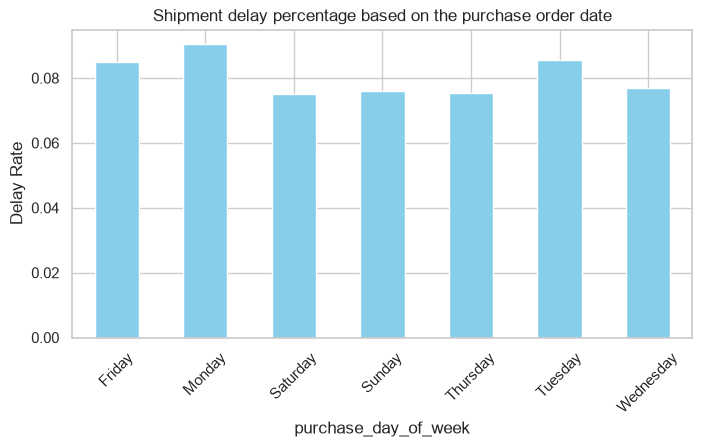

In [7]:
# استخراج يوم الأسبوع والشهر من تاريخ الشراء وتأثيرهما على التأخير
if "order_purchase_timestamp" in df.columns:
    df["purchase_day_of_week"] = df[
        "order_purchase_timestamp"
    ].dt.day_name()
    df["purchase_month"] = df["order_purchase_timestamp"].dt.month

    # حساب نسبة التأخير حسب يوم الأسبوع
    day_late = df.groupby("purchase_day_of_week")["is_late"].mean()

    plt.figure(figsize=(8, 4))
    day_late.plot(kind="bar", color="skyblue")
    plt.title("Shipment delay percentage based on the purchase order date")
    plt.ylabel("Delay Rate")
    plt.xticks(rotation=45)
    plt.show()

In [13]:
import os

os.makedirs("artifacts/eda_plots", exist_ok=True)

# حفظ رسم بياني توضيحي كـ Artifact لتقرير الـ EDA
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=state_late.reset_index().head(10),
    x="customer_state",
    y="late_rate",
    palette="magma",
    ax=ax,
)
ax.set_title("Top 10 States Late Delivery Rate")
plt.savefig("artifacts/eda_plots/top_states_late_rate.png", bbox_inches="tight")
plt.close()

print("/artifacts/eda_plots Finished Analizing EDA Successfully")
   

C:\Users\HADI\AppData\Local\Temp\ipykernel_6060\1603312410.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


/artifacts/eda_plots Finished Analizing EDA Successfully
